<a href="https://colab.research.google.com/github/srinivas019/TCN-TASKS/blob/main/student_marks_by_hours.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/Fardin-Data/Score-Prediction-through-Study-Hours/main/data/student_scores.csv"

df=pd.read_csv(url)

df.head()

,Hours,Scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30


In [4]:
df.shape

(25, 2)

In [5]:
df.isnull().sum()

,0
Hours,0
Scores,0


In [7]:
df.describe()

,Hours,Scores
count,25.000000,25.000000
mean,5.012000,51.480000
std,2.525094,25.286887
min,1.100000,17.000000
25%,2.700000,30.000000
50%,4.800000,47.000000
75%,7.400000,75.000000
max,9.200000,95.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Hours   25 non-null     float64
 1   Scores  25 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 532.0 bytes


In [10]:
df["Hours"].min()

1.1

In [12]:
df["Scores"].max()

95

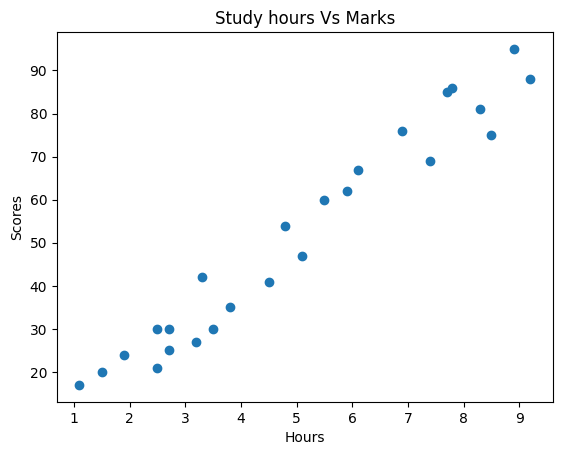

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.scatter(df['Hours'],df['Scores'])
plt.xlabel("Hours")
plt.ylabel("Scores")
plt.title("Study hours Vs Marks")
plt.show()

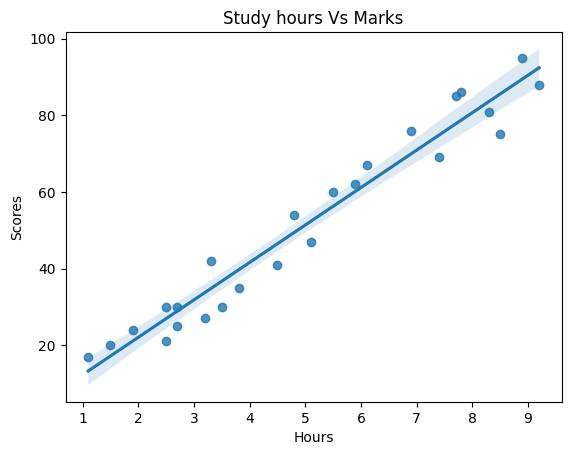

In [17]:
sns.regplot(x=df['Hours'],y=df['Scores'])
plt.xlabel("Hours")
plt.ylabel("Scores")
plt.title("Study hours Vs Marks")
plt.show()


In [19]:
X=df[["Hours"]]
y=df["Scores"]

X.head()
y.head()

,Scores
0,21
1,47
2,27
3,75
4,30


In [21]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [23]:
from sklearn.linear_model import LinearRegression

model=LinearRegression()
model.fit(X_train,y_train)
pred=model.predict(X_test)
pred

array([83.18814104, 27.03208774, 27.03208774, 69.63323162, 59.95115347])

In [27]:
from sklearn.metrics import mean_absolute_error
mae=mean_absolute_error(y_test,pred)
print("Mean Absolute Error:",mae)

Mean Absolute Error: 3.9207511902099244


In [28]:
from sklearn.metrics import r2_score
r2=r2_score(y_test,pred)
print("r2 score:",r2)

r2 score: 0.9678055545167994


In [32]:
from sklearn.preprocessing import PolynomialFeatures

poly=PolynomialFeatures(degree=2)
X_poly=poly.fit_transform(X)
X_poly.shape

(25, 3)

In [41]:
X_train_poly=poly.fit_transform(X_train)
X_test_poly=poly.transform(X_test)
model_poly=LinearRegression()
model_poly.fit(X_train_poly,y_train)
pred_poly=model_poly.predict(X_tese_poly)
pred_poly

array([83.49886042, 27.17108031, 27.17108031, 69.23573267, 59.30756364])

In [50]:
from sklearn.metrics import mean_absolute_error,r2_score
mae=mean_absolute_error(y_test,pred_poly)
print("Mean Absolute Error:",mae)
r2=r2_score(y_test,pred_poly)
print("r2 score:",r2)

Mean Absolute Error: 4.191112820294052
r2 score: 0.9641965165901752


In [51]:

print("Actual marks:")
print(y_test.head())

print("\nPredicted marks:")
print(pred_poly[:5])

print("\nShapes:")
print("y_test:", y_test.shape)
print("pred_poly:", pred_poly.shape)

print("\nMAE:", mean_absolute_error(y_test, pred_poly))
print("R2:", r2_score(y_test, pred_poly))


Actual marks:
8     81
16    30
0     21
23    76
11    62
Name: Scores, dtype: int64

Predicted marks:
[83.49886042 27.17108031 27.17108031 69.23573267 59.30756364]

Shapes:
y_test: (5,)
pred_poly: (5,)

MAE: 4.191112820294052
R2: 0.9641965165901752


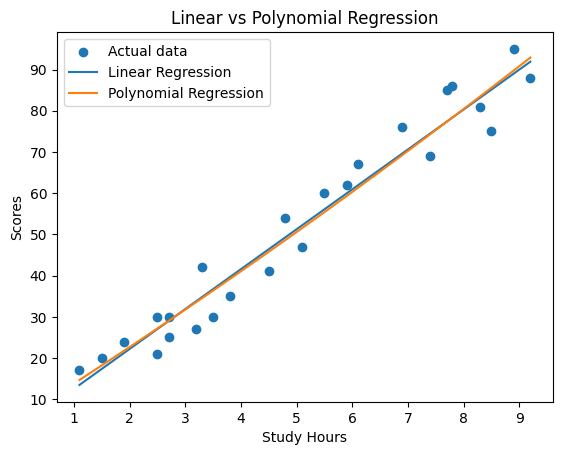

In [52]:
import numpy as np
import matplotlib.pyplot as plt

X_plot = pd.DataFrame({
    "Hours": np.linspace(
        df["Hours"].min(),
        df["Hours"].max(),
        300
    )
})

# Linear predictions - using 'model' instead of 'model_linear'
y_linear_plot = model.predict(X_plot)

# Polynomial predictions
X_plot_poly = poly.transform(X_plot)
y_poly_plot = model_poly.predict(X_plot_poly)

# Using 'Scores' instead of 'Marks'
plt.scatter(df["Hours"], df["Scores"], label="Actual data")
plt.plot(X_plot["Hours"], y_linear_plot, label="Linear Regression")
plt.plot(X_plot["Hours"], y_poly_plot, label="Polynomial Regression")

plt.xlabel("Study Hours")
plt.ylabel("Scores")
plt.title("Linear vs Polynomial Regression")
plt.legend()
plt.show()